In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import  TensorDataset, DataLoader

from classif_functions import auc_and_fpr_recall, calc_outputs_test, train

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Préparation des données

(Passage à **3 modalités**, **Near OOD**)

Le but ici est de passer à 3 modalités. Comme Kinetics n'est pas disponible et que HMDB n'a pas l'audio, on est obligé de faire du Near OOD. Et comme il n'a pas été procuré de modèle entraîné sur HAC en Near OOD, on est obligé de faire les expériences sur EPIC.

Même principe que far ood mais on a une dimension en plus (React(audio))

On charge les fichiers conf sur EPIC en Near OOD, mais provenant de différents splits. Le split "test" (de même que "train" qu'on utilisera pas) contient les classes 0 à 3 pour l'ID, et le split "eval" contient les classes de 4 à 7 pour l'OOD. 

In [3]:
root_dir = "/data/maouche/MultiOOD/EPIC-rgb-flow/saved_files/"
modalities = ['video', 'flow', "audio"] #

## Création des datasets

Données ID

In [35]:
template_sans_react =  "id_EPIC_near_ood_conf_vfa_baseline_best_test.npy"
template_react_tout = "id_EPIC_near_ood_conf_vfa_baseline_best_react_test.npy"
template_par_modalite = "id_EPIC_near_ood_conf_vfa_baseline_best_react_{}_test.npy"

# Sans react
conf_sans_react = np.load(root_dir+template_sans_react)
conf_sans_react = conf_sans_react.reshape(conf_sans_react.shape[0], 1)

# React sur tout
conf_react_tout = np.load(root_dir+template_react_tout)
conf_react_tout = conf_react_tout.reshape(conf_react_tout.shape[0], 1)


# React par modalité
conf_une_modalite = []
for modality in modalities:
    x = np.load(root_dir+template_par_modalite.format(modality))
    x = x.reshape(x.shape[0], 1)
    conf_une_modalite.append(x)
conf_une_modalite = np.hstack(conf_une_modalite)

dataset_id = np.hstack([conf_sans_react, conf_react_tout, conf_une_modalite]) #(N,5)

Données OOD

In [36]:
template_sans_react =  "id_EPIC_near_ood_conf_vfa_baseline_best_eval.npy"
template_react_tout = "id_EPIC_near_ood_conf_vfa_baseline_best_react_eval.npy"
template_par_modalite = "id_EPIC_near_ood_conf_vfa_baseline_best_react_{}_eval.npy"

# Sans react
conf_sans_react = np.load(root_dir+template_sans_react)
conf_sans_react = conf_sans_react.reshape(conf_sans_react.shape[0], 1)

# React sur tout
conf_react_tout = np.load(root_dir+template_react_tout)
conf_react_tout = conf_react_tout.reshape(conf_react_tout.shape[0], 1)


# React par modalité
conf_une_modalite = []
for modality in modalities:
    x = np.load(root_dir+template_par_modalite.format(modality))
    x = x.reshape(x.shape[0], 1)
    conf_une_modalite.append(x)
conf_une_modalite = np.hstack(conf_une_modalite)


dataset_ood = np.hstack([conf_sans_react, conf_react_tout, conf_une_modalite]) #(N,5)

In [41]:
X = np.vstack([dataset_id, dataset_ood])

Création des labels

In [ ]:
# inutile mais bon pour visualisation
template_label_id =  "id_EPIC_near_ood_label_vfa_baseline_best_test.npy"
labels_id = np.load(root_dir+template_label_id)

template_label_ood =  "id_EPIC_near_ood_label_vfa_baseline_best_eval.npy"
labels_ood = np.load(root_dir+template_label_ood)
print(np.unique(labels_id, return_counts=True), len(labels_id))
print(np.unique(labels_ood, return_counts=True), len(labels_ood))


(array([0, 1, 2, 3]), array([174, 211,  84,  67])) 536
(array([4, 5, 6, 7]), array([1053,  139,   54,   74])) 1320


In [51]:
y_id = np.zeros(dataset_id.shape[0])
y_id = y_id.reshape(y_id.shape[0], 1)

y_ood = np.ones(dataset_ood.shape[0])
y_ood = y_ood.reshape(y_ood.shape[0], 1)

Y = np.vstack([y_id, y_ood])

In [43]:
X.shape, Y.shape

((1856, 5), (1856, 1))

## Création des dataloaders

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                X, Y, stratify=Y, test_size=0.2, random_state=42)

data = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [ ]:
with open("data_vfa.pkl", 'wb') as f:
    pickle.dump(data, f)

# Chargement des données

In [3]:
with open('data_vfa.pkl', 'rb') as f:
    data = pickle.load(f)

In [54]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))


In [55]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
y_tensor_test = 1-y_tensor_test# pour classification binaire
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

372 elements (array([0., 1.], dtype=float32), array([265, 107]))


# Modèle

In [59]:
# Calcul des poids des classes
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.4066350710900474

In [ ]:
input_dim = 5 #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=0.1
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 50

<ipython-input-64-499b4285571f>:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes


# Entrainement

In [ ]:
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/torch/nn/functional.py:1944: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


accuracy train:  0.5406959220069519


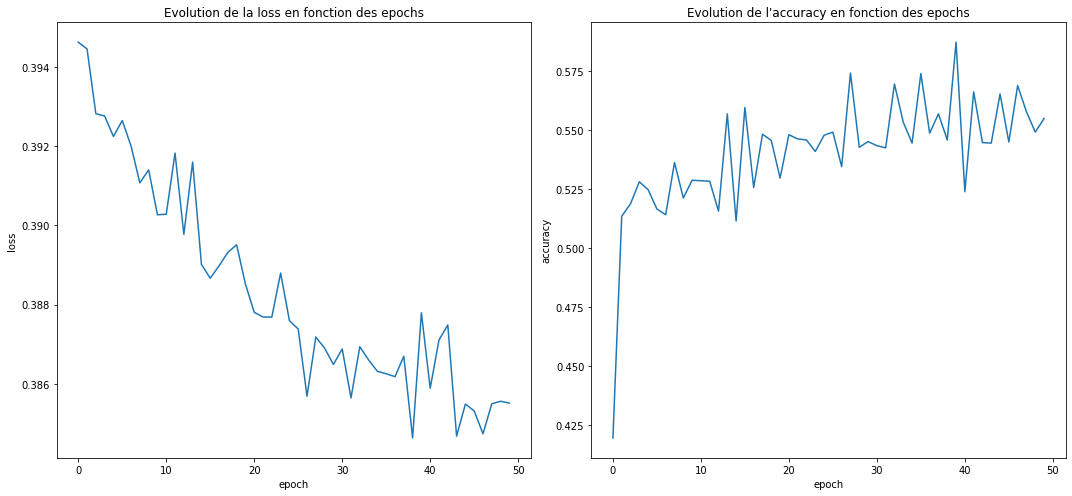

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].plot(np.arange(len(plot_loss)), plot_loss)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Evolution de la loss en fonction des epochs")

ax[1].plot(np.arange(len(plot_acc)), plot_acc)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Evolution de l'accuracy en fonction des epochs")

plt.tight_layout()
plt.show()


In [67]:
torch.save(model.state_dict(), "model_vfa.pth")

In [68]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-0.3192, -0.0850, -0.2925, -0.6136, -0.7615]])
bias
tensor([1.6822])


# Tests

### Séparabilité

In [ ]:
outputs_test = calc_outputs_test(model, test_dataloader)

# with open("outputs_test_vfa.pkl", 'wb') as f:
#     pickle.dump(outputs_test, f)

In [76]:
with open("outputs_test_vfa.pkl", 'rb') as f:
    outputs_test = pickle.load(f)

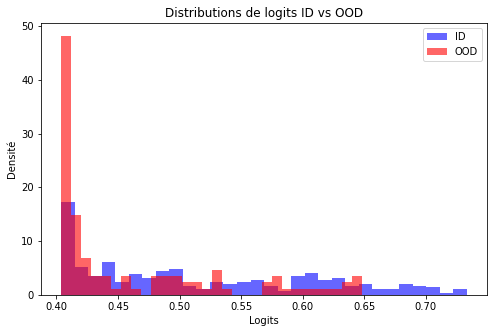

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(outputs_test["logits_id_test"], bins=30, alpha=0.6, label="ID", color='blue', density=True)
plt.hist(outputs_test["logits_ood_test"], bins=30, alpha=0.6, label="OOD", color='red', density=True)

plt.xlabel("Logits")
plt.ylabel("Densité")
plt.title("Distributions de logits ID vs OOD")
plt.legend()
plt.show()


### AUC & FPR

In [ ]:
auroc, aupr_in, aupr_out, fpr = auc_and_fpr_recall(np.array(outputs_test["all_outputs_test"]), np.array(outputs_test["all_labels_test"]), tpr_th=0.95)
auroc, fpr

(0.30072297654734614, 0.9962264150943396)

# Utiliser uniquement le flow et la vidéo pour entraîné le modèle même si le backbone est vfa

In [27]:
X_tensor_train = torch.tensor(data['X_train'][:,:-1], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 
X_tensor_train.shape

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))


torch.Size([1484, 4])

In [14]:
X_tensor_test = torch.tensor(data['X_test'][:,:-1], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
y_tensor_test = 1-y_tensor_test# pour classification binaire
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

372 elements (array([0., 1.], dtype=float32), array([265, 107]))


In [ ]:
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
pos_weight = counts[0] / counts[1] # N_negative / N_positive
input_dim = 4 #react sur tous + react sur aucun + react video + react flow
output_dim = 1
model = nn.Linear(input_dim, output_dim)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=0.1
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 50

0.4066350710900474

In [ ]:
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/torch/nn/functional.py:1944: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


accuracy train:  0.5075975176755418


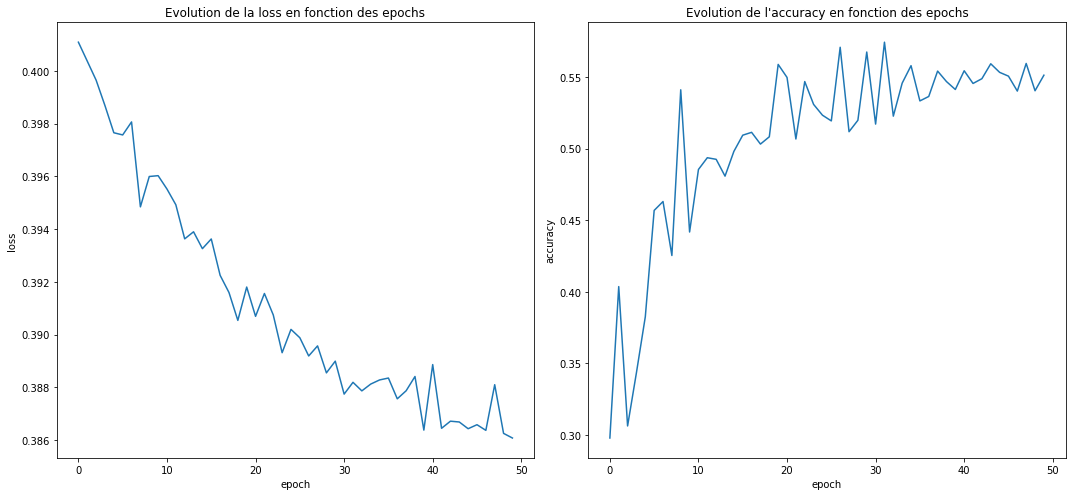

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].plot(np.arange(len(plot_loss)), plot_loss)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Evolution de la loss en fonction des epochs")

ax[1].plot(np.arange(len(plot_acc)), plot_acc)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Evolution de l'accuracy en fonction des epochs")

plt.tight_layout()
plt.show()


In [20]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-0.5206,  0.1675, -0.7920, -0.6616]])
bias
tensor([1.4655])


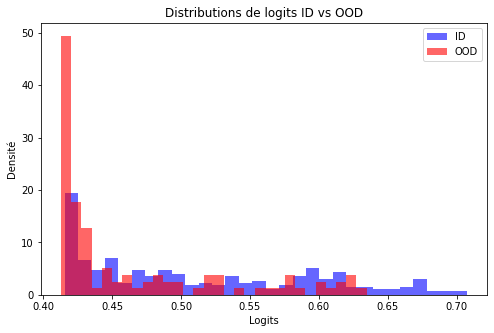

In [ ]:
outputs_test = calc_outputs_test(model, test_dataloader)
plt.figure(figsize=(8, 5))

plt.hist(outputs_test["logits_id_test"], bins=30, alpha=0.6, label="ID", color='blue', density=True)
plt.hist(outputs_test["logits_ood_test"], bins=30, alpha=0.6, label="OOD", color='red', density=True)

plt.xlabel("Logits")
plt.ylabel("Densité")
plt.title("Distributions de logits ID vs OOD")
plt.legend()
plt.show()


In [26]:
auroc, aupr_in, aupr_out, fpr = auc_and_fpr_recall(np.array(outputs_test["all_outputs_test"]), np.array(outputs_test["all_labels_test"]), tpr_th=0.95)
auroc, fpr

(0.29204725797919234, 1.0)